# 模型对比测试 Notebook

本 Notebook 用于系统性地对比微调后的模型与原始模型在目标检测任务上的性能。

## 测试维度
1. **数值量化对比**: IOU指标计算
2. **可视化效果对比**: 检测结果对比图像

---

## 0. 环境配置

In [1]:
import json
import os
import sys
import warnings
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np

warnings.filterwarnings("ignore")

try:
    from io import BytesIO

    import matplotlib.patches as patches
    import matplotlib.pyplot as plt
    import requests
    import torch
    from matplotlib.gridspec import GridSpec
    from PIL import Image, ImageDraw, ImageFont

    print("依赖加载成功")
    print(f"PyTorch版本: {torch.__version__}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(
            f"GPU内存: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB"
        )
except ImportError as e:
    print(f"缺少依赖: {e}")
    print("请安装: pip install torch pillow matplotlib requests numpy")
    sys.exit(1)

依赖加载成功
PyTorch版本: 2.10.0+cu128
GPU: NVIDIA RTX 5880 Ada Generation
GPU内存: 47.4 GB


## 1. IOU 计算模块

In [2]:
class IOUCalculator:
    """IOU(交并比)计算器"""

    @staticmethod
    def calculate_iou(box1: List[float], box2: List[float]) -> float:
        """计算两个边界框的IOU"""
        x1_1, y1_1, x2_1, y2_1 = box1
        x1_2, y1_2, x2_2, y2_2 = box2

        xi1 = max(x1_1, x1_2)
        yi1 = max(y1_1, y1_2)
        xi2 = min(x2_1, x2_2)
        yi2 = min(y2_1, y2_2)

        if xi2 <= xi1 or yi2 <= yi1:
            return 0.0

        inter_area = (xi2 - xi1) * (yi2 - yi1)
        box1_area = (x2_1 - x1_1) * (y2_1 - y1_1)
        box2_area = (x2_2 - x1_2) * (y2_2 - y1_2)
        union_area = box1_area + box2_area - inter_area

        return inter_area / union_area if union_area > 0 else 0.0

    @staticmethod
    def calculate_batch_iou(
        detections1: List[Dict], detections2: List[Dict]
    ) -> Dict[str, Any]:
        """批量计算两组检测结果的IOU"""
        if not detections1 or not detections2:
            return {
                "mean_iou": 0.0,
                "max_iou": 0.0,
                "min_iou": 0.0,
                "num_pairs": 0,
                "class_ious": {},
            }

        all_ious = []
        class_ious = {}

        for det1 in detections1:
            bbox1 = det1.get("bbox", [0, 0, 0, 0])
            label1 = det1.get("label", "unknown")

            best_iou = 0.0
            for det2 in detections2:
                bbox2 = det2.get("bbox", [0, 0, 0, 0])
                iou = IOUCalculator.calculate_iou(bbox1, bbox2)
                best_iou = max(best_iou, iou)

            if best_iou > 0:
                all_ious.append(best_iou)
                if label1 not in class_ious:
                    class_ious[label1] = []
                class_ious[label1].append(best_iou)

        class_stats = {}
        for label, ious in class_ious.items():
            class_stats[label] = {
                "mean_iou": np.mean(ious),
                "max_iou": np.max(ious),
                "min_iou": np.min(ious),
                "count": len(ious),
            }

        return {
            "mean_iou": float(np.mean(all_ious)) if all_ious else 0.0,
            "max_iou": float(np.max(all_ious)) if all_ious else 0.0,
            "min_iou": float(np.min(all_ious)) if all_ious else 0.0,
            "num_pairs": len(all_ious),
            "class_ious": class_stats,
        }

    @staticmethod
    def filter_by_confidence(detections: List[Dict], threshold: float) -> List[Dict]:
        """根据置信度阈值过滤检测结果"""
        return [det for det in detections if det.get("confidence", 0) >= threshold]


print("IOU计算器已初始化")

IOU计算器已初始化


## 2. 配置参数

修改以下配置单元格中的参数即可适配不同环境。所有路径基于 `PROJECT_ROOT` 自动推导。

**跨Notebook参数关联:**
- `BASE_MODEL_PATH`: 与 **02-微调** 和 **03-推理** Notebook 中的基础模型路径保持一致
- `LORA_ADAPTER_PATH`: 由 **02-微调** Notebook 生成的 LoRA 适配器路径

In [3]:
# ============================================================
# 项目路径与全局配置
# ============================================================
# 【重要】修改以下参数即可适配不同环境，无需改动其他单元格

from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

# 定位项目根目录: 优先搜索 cwd, 其次搜索 VS Code notebook 文件路径
_nb_file = globals().get('__vsc_ipynb_file__', '')
_search_starts = [NOTEBOOK_DIR] + ([Path(_nb_file).parent] if _nb_file else [])
PROJECT_ROOT = None
for _s in _search_starts:
    for _p in [_s] + list(_s.parents):
        if (_p / 'pyproject.toml').exists():
            PROJECT_ROOT = _p
            break
    if PROJECT_ROOT:
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = NOTEBOOK_DIR.parent  # fallback: assume cwd is <root>/notebooks/

# ---------- 模型路径配置 ----------
# 基础模型路径 (与02-微调/03-推理Notebook中的BASE_MODEL_PATH一致)
# BASE_MODEL_PATH = "unsloth/gemma-4-E4B-it-bnb-4bit"  # HuggingFace在线模型 (推荐)
BASE_MODEL_PATH = "/raid5/sh/model/unsloth/gemma-4-E4B-it-unsloth-bnb-4bit"
# BASE_MODEL_PATH = str(PROJECT_ROOT / "models" / "base" / "gemma-4-E4B-it-unsloth-bnb-4bit")  # 本地路径

# LoRA适配器路径 (由02-微调Notebook生成)
LORA_ADAPTER_PATH = str(PROJECT_ROOT / "models" / "finetuned" / "gemma4_e4b_lora")

# ---------- 模型加载参数 ----------
MAX_SEQ_LENGTH = 2048  # 最大序列长度
LOAD_IN_4BIT = True  # 是否使用4-bit量化
DEVICE_MAP = "cuda:0"  # 设备映射 (可选: "cuda:0", "balanced", "auto")

# ---------- 推理参数 ----------
INFERENCE_MAX_NEW_TOKENS = 512  # 推理最大生成token数
INFERENCE_TEMPERATURE = 0.7  # 推理温度 (取值范围: 0-2)
INFERENCE_TOP_P = 0.9  # 推理top_p (取值范围: 0-1)

# ---------- 测试数据配置 ----------
TEST_DATA = [
    {
        "source": "https://fsimage.guihuao.com/images/28b37a22-2e2e-4adc-8e94-eedc986d26a9/5147493742738931713.jpeg?imageMogr2/crop/!1353x1353a1311a823",
        "query": "检测图中的水面绿藻,使用green algae作为标签",
        "ground_truth": [
            {"bbox": [0, 603, 1353, 749], "label": "green algae", "confidence": 1.0}
        ],
    }
]

# ---------- 评估参数 ----------
CONFIDENCE_THRESHOLDS = [0.5, 0.7, 0.85, 0.95]  # 置信度阈值列表 (用于阈值分析)

print(f"项目根目录: {PROJECT_ROOT}")
print(f"基础模型: {BASE_MODEL_PATH}")
print(f"LoRA适配器: {LORA_ADAPTER_PATH}")

项目根目录: /raid5/sh/code/vlm-detect
基础模型: /raid5/sh/model/unsloth/gemma-4-E4B-it-unsloth-bnb-4bit
LoRA适配器: /raid5/sh/code/vlm-detect/models/finetuned/gemma4_e4b_lora


## 3. 模型配置

所有模型路径参数已在上方 **0. 配置参数** 单元格中集中定义，`MODEL_CONFIG` 自动读取这些值。

In [4]:
# 模型配置
# ============================================================
# 所有路径参数已在上方配置单元格中集中定义

MODEL_CONFIG = {
    "base_model": {
        "name": "原始模型",
        "base_model_path": BASE_MODEL_PATH,
        "max_seq_length": MAX_SEQ_LENGTH,
        "load_in_4bit": LOAD_IN_4BIT,
        "device_map": DEVICE_MAP,
    },
    "finetuned_model": {
        "name": "微调模型",
        "base_model_path": BASE_MODEL_PATH,
        "lora_adapter_path": LORA_ADAPTER_PATH,
        "max_seq_length": MAX_SEQ_LENGTH,
        "load_in_4bit": LOAD_IN_4BIT,
        "device_map": DEVICE_MAP,
    },
}

print("配置已加载")
print(f"  基础模型: {BASE_MODEL_PATH}")
print(f"  LoRA适配器: {LORA_ADAPTER_PATH}")

配置已加载
  基础模型: /raid5/sh/model/unsloth/gemma-4-E4B-it-unsloth-bnb-4bit
  LoRA适配器: /raid5/sh/code/vlm-detect/models/finetuned/gemma4_e4b_lora


## 4. 模型加载模块

In [5]:
class ModelLoader:
    """视觉模型加载器"""

    def __init__(self, config: Dict[str, Any]):
        self.config = config
        self.model = None
        self.processor = None
        self._is_loaded = False

    def _patch_peft_for_gemma4(self) -> bool:
        """
        修复PEFT对Gemma4ClippableLinear的支持

        使用类名字符串匹配代替isinstance, 避免Unsloth monkey-patch导致的类身份不匹配
        注意: _create_new_module 是静态方法, 必须用 staticmethod() 替代
        """
        try:
            from peft.tuners.lora import model as lora_model

            _original = lora_model.LoraModel._create_new_module

            def _patch(lora_config, adapter_name, target, **kwargs):
                # 使用类名字符串匹配 + hasattr检查, 避免isinstance因Unsloth patch导致的类身份不匹配
                if target.__class__.__name__ == "Gemma4ClippableLinear" and hasattr(target, "linear"):
                    return _original(lora_config, adapter_name, target.linear, **kwargs)
                return _original(lora_config, adapter_name, target, **kwargs)

            lora_model.LoraModel._create_new_module = staticmethod(_patch)
            print("PEFT已patch,支持Gemma4ClippableLinear")
            return True
        except Exception as e:
            print(f"Patch失败: {e}")
            return False

    def load_model(self) -> bool:
        """加载视觉模型"""
        try:
            print(f'正在加载模型: {self.config.get("name", "Unknown")}')
            os.environ["UNSLOTH_DISABLE_STATISTICS"] = "1"

            from unsloth import FastVisionModel

            base_path = self.config["base_model_path"]
            lora_path = self.config.get("lora_adapter_path", None)

            self.model, self.processor = FastVisionModel.from_pretrained(
                model_name=base_path,
                max_seq_length=self.config["max_seq_length"],
                load_in_4bit=self.config["load_in_4bit"],
                device_map=self.config["device_map"],
                disable_log_stats=True,
            )

            if lora_path and os.path.exists(lora_path):
                print(f"正在加载 LoRA adapter: {lora_path}")
                self._patch_peft_for_gemma4()
                from peft import PeftModel

                self.model = PeftModel.from_pretrained(
                    self.model, lora_path, is_trainable=False
                )
                print("LoRA adapter 加载成功")

            self._is_loaded = True
            return True
        except Exception as e:
            print(f"模型加载失败: {e}")
            import traceback

            traceback.print_exc()
            return False

    def is_loaded(self) -> bool:
        return self._is_loaded

## 5. 目标检测模块

In [6]:
class ObjectDetector:
    """目标检测器"""

    def __init__(self, model_loader: ModelLoader):
        self.model_loader = model_loader

    def _build_prompt(self, query: str) -> str:
        prompt = f"""请仔细分析这张图片,{query}。

如果检测到目标,请严格按照以下JSON格式返回检测结果(不要添加其他文字说明):
[
  {{"box_2d": [y1, x1, y2, x2], "label": "目标类别", "confidence": 置信度}}
]

坐标说明:
- box_2d: 边界框坐标 [y1, x1, y2, x2],基于1000x1000坐标系
- y1, y2: 垂直方向坐标 (0-1000),y1 < y2
- x1, x2: 水平方向坐标 (0-1000),x1 < x2
- confidence: 置信度分数 (0.0-1.0)

如果未检测到目标,请返回空数组: []"""
        return prompt

    def detect(
        self, image: Image.Image, query: str, max_new_tokens: int = 512
    ) -> Dict[str, Any]:
        if not self.model_loader.is_loaded():
            return {"error": "模型未加载", "success": False}

        try:
            model = self.model_loader.model
            processor = self.model_loader.processor

            prompt = self._build_prompt(query)
            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": image},
                        {"type": "text", "text": prompt},
                    ],
                }
            ]

            inputs = processor.apply_chat_template(
                messages,
                tokenize=True,
                add_generation_prompt=True,
                return_tensors="pt",
                return_dict=True,
            ).to(model.device)

            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    use_cache=True,
                    temperature=0.7,
                    top_p=0.9,
                    do_sample=True,
                )

            response = processor.batch_decode(outputs, skip_special_tokens=True)[0]
            width, height = image.size
            detections = self._parse_response(response, query, width, height)

            return {
                "success": True,
                "raw_response": response,
                "detections": detections,
                "query": query,
            }
        except Exception as e:
            return {"error": str(e), "success": False}

    def _parse_response(
        self, response: str, query: str, width: int, height: int
    ) -> List[Dict[str, Any]]:
        import re

        detections = []
        scale_1000_x = width / 1000.0
        scale_1000_y = height / 1000.0

        def _is_normalized(coords: list) -> bool:
            return all(0 <= v <= 1 for v in coords)

        def _convert_coords(coords: list, w: int, h: int) -> tuple:
            if _is_normalized(coords):
                x1 = int(coords[1] * w)
                y1 = int(coords[0] * h)
                x2 = int(coords[3] * w)
                y2 = int(coords[2] * h)
            else:
                x1 = int(coords[1] * scale_1000_x)
                y1 = int(coords[0] * scale_1000_y)
                x2 = int(coords[3] * scale_1000_x)
                y2 = int(coords[2] * scale_1000_y)
            return (x1, y1, x2, y2)

        def _extract_json_array(text: str) -> Optional[str]:
            json_block = re.search(r"```json\s*([\s\S]*?)\s*```", text)
            if json_block:
                return json_block.group(1).strip()

            start_idx = text.find("[")
            if start_idx == -1:
                return None

            bracket_count = 0
            for i, char in enumerate(text[start_idx:], start_idx):
                if char == "[":
                    bracket_count += 1
                elif char == "]":
                    bracket_count -= 1
                    if bracket_count == 0:
                        return text[start_idx : i + 1]
            return None

        json_str = _extract_json_array(response)
        if json_str:
            try:
                json_data = json.loads(json_str)
                for item in json_data:
                    if "box_2d" in item and len(item["box_2d"]) == 4:
                        coords = item["box_2d"]
                        label = item.get("label", "目标")
                        confidence = item.get("confidence", 0.85)
                        x1, y1, x2, y2 = _convert_coords(coords, width, height)
                        if 0 <= x1 < width and 0 <= y1 < height:
                            detections.append(
                                {
                                    "bbox": [x1, y1, x2, y2],
                                    "label": label,
                                    "confidence": min(confidence, 1.0),
                                }
                            )
                if detections:
                    return detections
            except (json.JSONDecodeError, KeyError, TypeError):
                pass

        return detections

## 6. 可视化对比模块

In [7]:
class ComparisonVisualizer:
    """检测结果可视化对比器"""

    COLORS = [
        "#FF3838",
        "#FF9D00",
        "#FF701F",
        "#FFB21D",
        "#CFD231",
        "#48F90A",
        "#92CC17",
        "#3DDB86",
        "#1A9F34",
        "#00D4BB",
    ]

    def draw_detections(
        self, image: Image.Image, detections: List[Dict]
    ) -> Image.Image:
        if not detections:
            return image

        img_draw = image.copy()
        draw = ImageDraw.Draw(img_draw)

        try:
            font = ImageFont.load_default(size=16)
        except:
            font = ImageFont.load_default()

        for i, det in enumerate(detections):
            bbox = det.get("bbox", [0, 0, 0, 0])
            label = det.get("label", "未知")
            confidence = det.get("confidence", 0)

            if len(bbox) == 4:
                x1, y1, x2, y2 = int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])
            else:
                continue

            color = self.COLORS[i % len(self.COLORS)]

            draw.rectangle([x1, y1, x2, y2], outline=color, width=3)

            text = f"{label} {confidence:.0%}"
            text_bbox = draw.textbbox((x1, y1), text, font=font)
            text_width = text_bbox[2] - text_bbox[0]
            text_height = text_bbox[3] - text_bbox[1]

            fill_y1 = y1 - text_height - 4
            if fill_y1 < 0:
                fill_y1 = y1 + 4
            fill_y2 = fill_y1 + text_height + 2

            draw.rectangle([x1, fill_y1, x1 + text_width + 4, fill_y2], fill=color)
            draw.text((x1 + 2, fill_y1 + 1), text, fill="white", font=font)

        return img_draw

    def create_comparison_plot(
        self,
        image: Image.Image,
        det_base: List[Dict],
        det_finetuned: List[Dict],
        iou_stats: Dict,
    ):
        """创建对比可视化图"""
        fig = plt.figure(figsize=(16, 10))
        gs = GridSpec(2, 2, figure=fig, height_ratios=[3, 1])

        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])

        img_base = self.draw_detections(image, det_base)
        img_finetuned = self.draw_detections(image, det_finetuned)

        ax1.imshow(img_base)
        ax1.set_title(
            f"原始模型\n检测数量: {len(det_base)}", fontsize=12, fontweight="bold"
        )
        ax1.axis("off")

        ax2.imshow(img_finetuned)
        ax2.set_title(
            f"微调模型\n检测数量: {len(det_finetuned)}", fontsize=12, fontweight="bold"
        )
        ax2.axis("off")

        ax3 = fig.add_subplot(gs[1, :])

        stats_text = f"IOU统计:\n"
        stats_text += f'平均IOU: {iou_stats.get("mean_iou", 0):.3f}\n'
        stats_text += f'最大IOU: {iou_stats.get("max_iou", 0):.3f}\n'
        stats_text += f'最小IOU: {iou_stats.get("min_iou", 0):.3f}\n'
        stats_text += f'匹配数量: {iou_stats.get("num_pairs", 0)}\n'

        if iou_stats.get("class_ious"):
            stats_text += "\n类别级IOU:\n"
            for label, stats in iou_stats["class_ious"].items():
                stats_text += f'  {label}: {stats.get("mean_iou", 0):.3f}\n'

        ax3.text(
            0.5,
            0.5,
            stats_text,
            ha="center",
            va="center",
            fontsize=11,
            family="monospace",
        )
        ax3.axis("off")

        plt.tight_layout()
        plt.show()


print("可视化对比器已初始化")

可视化对比器已初始化


## 7. 加载模型

In [8]:
# 初始化模型加载器
model_loader_base = ModelLoader(MODEL_CONFIG["base_model"])
model_loader_finetuned = ModelLoader(MODEL_CONFIG["finetuned_model"])

# 加载原始模型
print("\n" + "=" * 60)
print("加载原始模型")
print("=" * 60)
success_base = model_loader_base.load_model()

# 加载微调模型
print("\n" + "=" * 60)
print("加载微调模型")
print("=" * 60)
success_finetuned = model_loader_finetuned.load_model()

if success_base and success_finetuned:
    print("\n所有模型加载成功!")
    detector_base = ObjectDetector(model_loader_base)
    detector_finetuned = ObjectDetector(model_loader_finetuned)
    visualizer = ComparisonVisualizer()
else:
    print("\n模型加载失败,请检查配置")


加载原始模型
正在加载模型: 原始模型
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.6: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX 5880 Ada Generation. Num GPUs = 8. Max memory: 47.372 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]


加载微调模型
正在加载模型: 微调模型
==((====))==  Unsloth 2026.4.6: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX 5880 Ada Generation. Num GPUs = 8. Max memory: 47.372 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

正在加载 LoRA adapter: /raid5/sh/code/vlm-detect/models/finetuned/gemma4_e4b_lora
PEFT已patch,支持Gemma4ClippableLinear
LoRA adapter 加载成功

所有模型加载成功!


## 8. 运行对比测试


测试图像: https://fsimage.guihuao.com/images/28b37a22-2e2e-4adc-8e94-eedc986d26a9/5147493742738931713.jpeg?imageMogr2/crop/!1353x1353a1311a823
检测查询: 检测图中的水面绿藻,使用green algae作为标签
图像尺寸: (1353, 1353)

原始模型检测...
微调模型检测...

检测结果:
原始模型检测数: 1
微调模型检测数: 1
真实标注数: 1

IOU指标 (相对于真实标注):
原始模型: 平均IOU=0.999
微调模型: 平均IOU=0.872
改进: -0.127


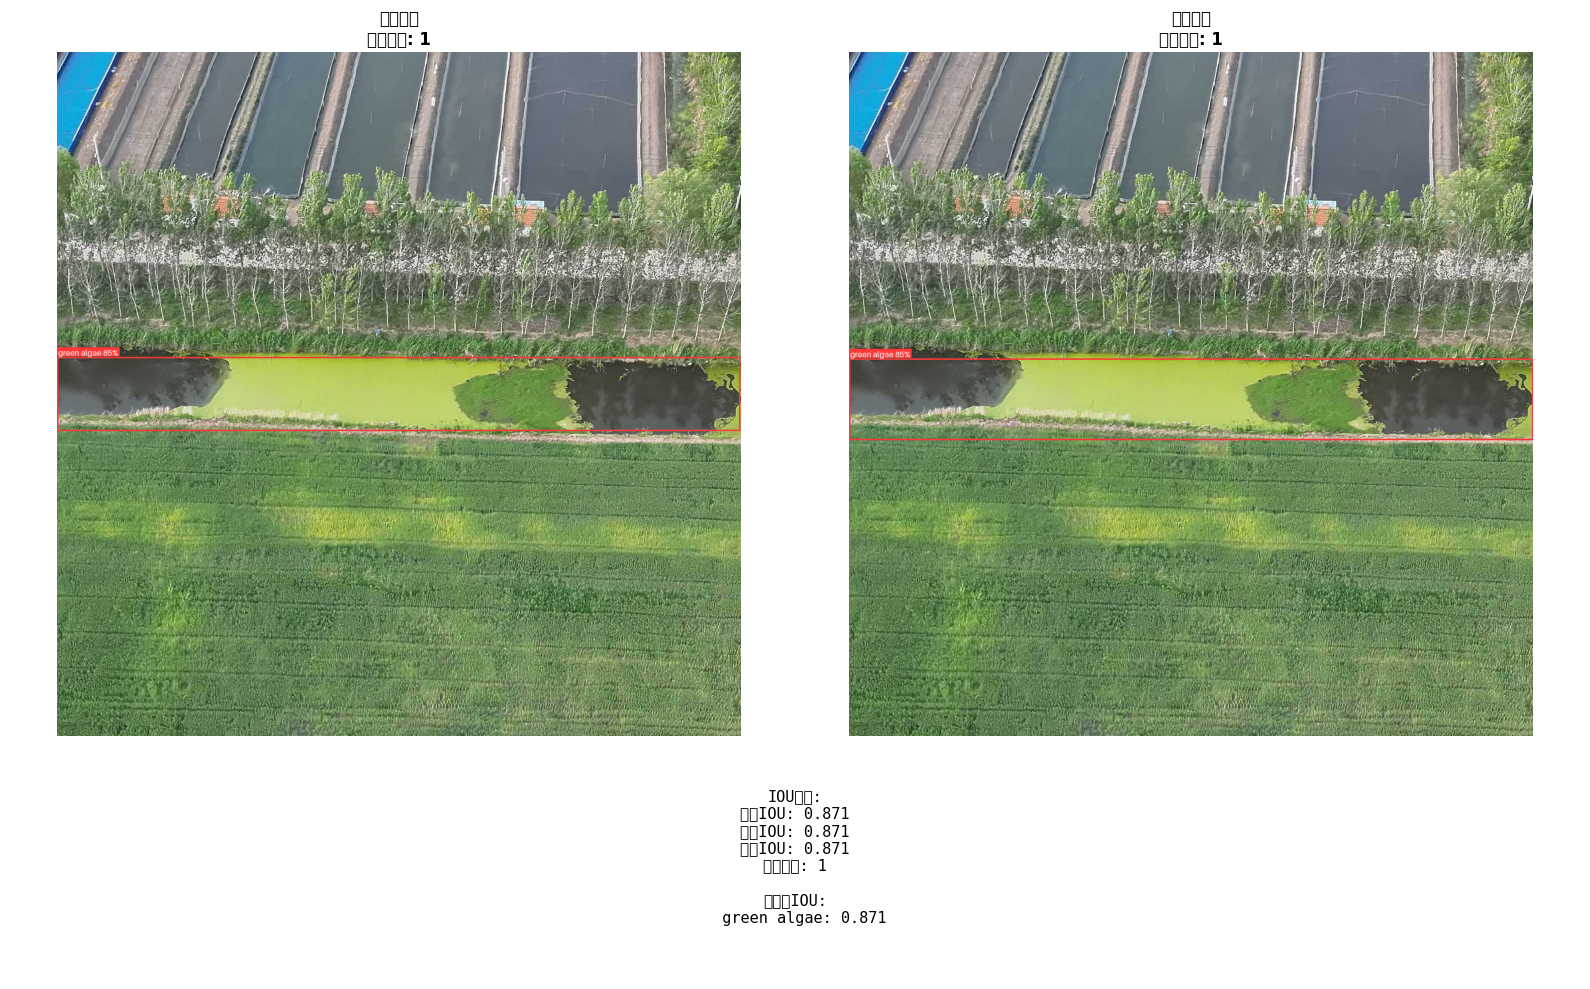

In [9]:
def run_comparison_test(test_item: Dict[str, Any]):
    """运行单个对比测试"""
    print("\n" + "=" * 60)
    print(f'测试图像: {test_item.get("source")}')
    print(f'检测查询: {test_item.get("query")}')
    print("=" * 60)

    # 加载图像
    try:
        source = test_item["source"]
        if source.startswith("http://") or source.startswith("https://"):
            response = requests.get(source, timeout=30)
            response.raise_for_status()
            image = Image.open(BytesIO(response.content)).convert("RGB")
        else:
            image = Image.open(source).convert("RGB")
        print(f"图像尺寸: {image.size}")
    except Exception as e:
        print(f"图像加载失败: {e}")
        return None

    # 运行检测
    print("\n原始模型检测...")
    result_base = detector_base.detect(image, test_item["query"])

    print("微调模型检测...")
    result_finetuned = detector_finetuned.detect(image, test_item["query"])

    if not result_base.get("success") or not result_finetuned.get("success"):
        print("检测失败")
        return None

    det_base = result_base.get("detections", [])
    det_finetuned = result_finetuned.get("detections", [])
    ground_truth = test_item.get("ground_truth", [])

    # 计算IOU
    iou_base_vs_gt = IOUCalculator.calculate_batch_iou(det_base, ground_truth)
    iou_finetuned_vs_gt = IOUCalculator.calculate_batch_iou(det_finetuned, ground_truth)
    iou_base_vs_finetuned = IOUCalculator.calculate_batch_iou(det_base, det_finetuned)

    # 打印结果
    print("\n检测结果:")
    print(f"原始模型检测数: {len(det_base)}")
    print(f"微调模型检测数: {len(det_finetuned)}")
    print(f"真实标注数: {len(ground_truth)}")

    print("\nIOU指标 (相对于真实标注):")
    print(f'原始模型: 平均IOU={iou_base_vs_gt.get("mean_iou", 0):.3f}')
    print(f'微调模型: 平均IOU={iou_finetuned_vs_gt.get("mean_iou", 0):.3f}')
    print(
        f'改进: {iou_finetuned_vs_gt.get("mean_iou", 0) - iou_base_vs_gt.get("mean_iou", 0):.3f}'
    )

    # 显示对比图
    visualizer.create_comparison_plot(
        image, det_base, det_finetuned, iou_base_vs_finetuned
    )

    return {
        "image": image,
        "det_base": det_base,
        "det_finetuned": det_finetuned,
        "ground_truth": ground_truth,
        "iou_base_vs_gt": iou_base_vs_gt,
        "iou_finetuned_vs_gt": iou_finetuned_vs_gt,
        "iou_base_vs_finetuned": iou_base_vs_finetuned,
    }


# 运行测试
test_results = []
for test_item in TEST_DATA:
    result = run_comparison_test(test_item)
    if result:
        test_results.append(result)

## 9. 置信度阈值分析

In [10]:
def analyze_confidence_thresholds(test_results: List[Dict]):
    """分析不同置信度阈值下的表现"""
    thresholds = CONFIDENCE_THRESHOLDS  # 使用配置单元格中定义的阈值

    print("\n" + "=" * 60)
    print("置信度阈值分析")
    print("=" * 60)

    for threshold in thresholds:
        print(f"\n置信度阈值: {threshold}")

        all_base_iou = []
        all_finetuned_iou = []
        all_base_count = []
        all_finetuned_count = []

        for result in test_results:
            det_base_filtered = IOUCalculator.filter_by_confidence(
                result["det_base"], threshold
            )
            det_finetuned_filtered = IOUCalculator.filter_by_confidence(
                result["det_finetuned"], threshold
            )

            iou_base = IOUCalculator.calculate_batch_iou(
                det_base_filtered, result["ground_truth"]
            )
            iou_finetuned = IOUCalculator.calculate_batch_iou(
                det_finetuned_filtered, result["ground_truth"]
            )

            all_base_iou.append(iou_base.get("mean_iou", 0))
            all_finetuned_iou.append(iou_finetuned.get("mean_iou", 0))
            all_base_count.append(len(det_base_filtered))
            all_finetuned_count.append(len(det_finetuned_filtered))

        avg_base_iou = np.mean(all_base_iou) if all_base_iou else 0
        avg_finetuned_iou = np.mean(all_finetuned_iou) if all_finetuned_iou else 0
        avg_base_count = np.mean(all_base_count) if all_base_count else 0
        avg_finetuned_count = np.mean(all_finetuned_count) if all_finetuned_count else 0

        print(f"原始模型: 平均IOU={avg_base_iou:.3f}, 平均检测数={avg_base_count:.1f}")
        print(
            f"微调模型: 平均IOU={avg_finetuned_iou:.3f}, 平均检测数={avg_finetuned_count:.1f}"
        )
        print(f"IOU改进: {avg_finetuned_iou - avg_base_iou:.3f}")


# 运行分析
if test_results:
    analyze_confidence_thresholds(test_results)


置信度阈值分析

置信度阈值: 0.5
原始模型: 平均IOU=0.999, 平均检测数=1.0
微调模型: 平均IOU=0.872, 平均检测数=1.0
IOU改进: -0.127

置信度阈值: 0.7
原始模型: 平均IOU=0.999, 平均检测数=1.0
微调模型: 平均IOU=0.872, 平均检测数=1.0
IOU改进: -0.127

置信度阈值: 0.85
原始模型: 平均IOU=0.999, 平均检测数=1.0
微调模型: 平均IOU=0.872, 平均检测数=1.0
IOU改进: -0.127

置信度阈值: 0.95
原始模型: 平均IOU=0.000, 平均检测数=0.0
微调模型: 平均IOU=0.000, 平均检测数=0.0
IOU改进: 0.000


## 10. 综合测试报告

In [11]:
def generate_summary_report(test_results: List[Dict]):
    """生成综合测试报告"""
    if not test_results:
        print("没有测试结果")
        return

    print("\n" + "=" * 70)
    print("模型对比测试综合报告")
    print("=" * 70)

    # 测试概况
    print(f"\n测试概况:")
    print(f"  测试样本数: {len(test_results)}")

    # 整体IOU统计
    all_base_iou = [r["iou_base_vs_gt"].get("mean_iou", 0) for r in test_results]
    all_finetuned_iou = [
        r["iou_finetuned_vs_gt"].get("mean_iou", 0) for r in test_results
    ]

    print(f"\n整体IOU表现 (相对于真实标注):")
    print(f"  原始模型:")
    print(f"    平均IOU: {np.mean(all_base_iou):.3f} ± {np.std(all_base_iou):.3f}")
    print(f"    IOU范围: [{np.min(all_base_iou):.3f}, {np.max(all_base_iou):.3f}]")

    print(f"  微调模型:")
    print(
        f"    平均IOU: {np.mean(all_finetuned_iou):.3f} ± {np.std(all_finetuned_iou):.3f}"
    )
    print(
        f"    IOU范围: [{np.min(all_finetuned_iou):.3f}, {np.max(all_finetuned_iou):.3f}]"
    )

    # 性能改进
    improvement = np.mean(all_finetuned_iou) - np.mean(all_base_iou)
    improvement_percent = (
        (improvement / np.mean(all_base_iou) * 100) if np.mean(all_base_iou) > 0 else 0
    )

    print(f"\n性能改进:")
    print(f"  IOU提升: {improvement:.3f}")
    print(f"  改进百分比: {improvement_percent:.1f}%")

    # 类别级分析
    class_stats = {}
    for result in test_results:
        for label, stats in result["iou_base_vs_gt"].get("class_ious", {}).items():
            if label not in class_stats:
                class_stats[label] = {"base": [], "finetuned": []}
            class_stats[label]["base"].append(stats.get("mean_iou", 0))

        for label, stats in result["iou_finetuned_vs_gt"].get("class_ious", {}).items():
            if label not in class_stats:
                class_stats[label] = {"base": [], "finetuned": []}
            class_stats[label]["finetuned"].append(stats.get("mean_iou", 0))

    if class_stats:
        print(f"\n类别级IOU表现:")
        for label, stats in class_stats.items():
            base_avg = np.mean(stats["base"]) if stats["base"] else 0
            finetuned_avg = np.mean(stats["finetuned"]) if stats["finetuned"] else 0
            print(f"  {label}:")
            print(f"    原始模型: {base_avg:.3f}")
            print(f"    微调模型: {finetuned_avg:.3f}")
            print(f"    改进: {finetuned_avg - base_avg:.3f}")

    print("\n" + "=" * 70)


# 生成报告
if test_results:
    generate_summary_report(test_results)


模型对比测试综合报告

测试概况:
  测试样本数: 1

整体IOU表现 (相对于真实标注):
  原始模型:
    平均IOU: 0.999 ± 0.000
    IOU范围: [0.999, 0.999]
  微调模型:
    平均IOU: 0.872 ± 0.000
    IOU范围: [0.872, 0.872]

性能改进:
  IOU提升: -0.127
  改进百分比: -12.7%

类别级IOU表现:
  green algae:
    原始模型: 0.999
    微调模型: 0.872
    改进: -0.127



---

# 总结

本 Notebook 提供了完整的模型对比测试流程:
1. 加载原始模型和微调模型
2. 对测试数据进行目标检测
3. 计算 IOU 指标进行量化对比
4. 生成可视化对比图像
5. 分析不同置信度阈值下的表现
6. 生成综合测试报告

通过这个系统,可以全面评估微调模型相对于原始模型的性能改进。